In [2]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
# from Perceptrons import Perceptron
import numpy as np
from collections import Counter

In [3]:
class Perceptron:
    def __init__(self, weights, bias=1, learning_rate=0.3):
        """
        'weights' can be a numpy array, list or tuple with the actual values of the weights. The number of input values
        is indirectly defined by the length of 'weights'
        """
        self.weights = np.array(weights)
        self.bias = bias
        self.learning_rate = learning_rate

    @staticmethod
    def unit_step_function(x):
        if x <= 0:
            return 0
        else:
            return 1

    def __call__(self, in_data):
        in_data = np.concatenate((in_data, [self.bias]))    # concat the bias value - here it is 1
        # print('in_data', in_data)                         # now it is ex : [0 0 1]
        result = self.weights @ in_data                     # multiply matrix [ ] [ ]  - same size arrays
        # print('results', result)                            # exercise 1 example :  0.4384837125193516
        return Perceptron.unit_step_function(result)

    def adjust(self, target_result, in_data):
        if type(in_data) != np.ndarray:
            in_data = np.array(in_data)
        calculated_result = self(in_data)
        # print(calculated_result)
        error = target_result - calculated_result
        if error != 0:
            in_data = np.concatenate((in_data, [self.bias]))
            correction = error * in_data * self.learning_rate
            self.weights += correction

    def evaluate(self, data, labels):
        evaluation = Counter()
        for sample, label in zip(data, labels):
            result = self(sample)  # predict
            if result == label:
                evaluation["correct"] += 1
            else:
                evaluation["wrong"] += 1
        return evaluation


In [9]:
n_samples = 250
samples, labels = make_blobs(n_samples=n_samples, centers=([2.5, 3], [6.7, 7.9]), random_state=0)

print(samples)        
print(labels)         

[[ 2.11267318  2.69769725]
 [ 3.63940068  1.76517418]
 [ 5.68195812  7.82214524]
 [ 4.03277921  4.46935877]
 [ 4.04082776  8.50631952]
 [ 3.11407937  3.92220667]
 [ 3.99407907  2.79484174]
 [ 1.68663574  1.53357567]
 [ 7.16313033  8.17909576]
 [ 7.22106488  7.32421203]
 [ 1.544055    2.65401822]
 [ 2.64404357  4.45427351]
 [ 6.13068795  8.16990435]
 [ 6.04759142  7.50904662]
 [ 6.61406923  8.09429294]
 [ 1.63877431  4.91006495]
 [ 4.76372019  8.0887786 ]
 [ 5.00189418  8.28728048]
 [ 6.30055097  8.27005589]
 [ 6.65429604  8.12050766]
 [ 2.06484645  4.84926373]
 [ 0.88610215  2.78725972]
 [ 6.1971833  10.31245368]
 [ 5.98039561  7.08700701]
 [ 3.67877957  2.82007516]
 [ 1.32687659  4.94362119]
 [ 1.90268393  2.76207827]
 [ 6.84195316  7.58067158]
 [ 2.79823817  4.3263859 ]
 [ 6.65782855  7.61311281]
 [ 6.97451636  7.00908492]
 [ 1.98919486  1.81936782]
 [ 7.52158571  7.90529265]
 [ 1.80543214  2.85036546]
 [ 5.97440262  6.51663604]
 [ 4.26405235  3.40015721]
 [ 7.47325298  6.71611936]
 

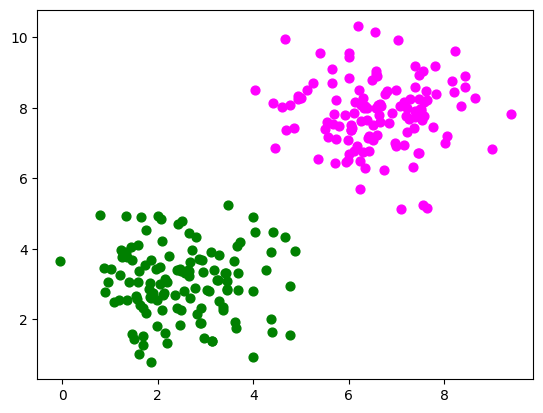

In [14]:
# let us visualize the previously created data
colours = ('green', 'magenta', 'blue', 'cyan', 'yellow', 'red')
fig, ax = plt.subplots()

for n_class in range(2):
    ax.scatter(samples[labels == n_class][:, 0], samples[labels == n_class][:, 1], c=colours[n_class],
               s=40, label=str(n_class))
    
plt.plot()
plt.show()

In [18]:
n_learn_data = int(n_samples * 0.8)    # 80  % of available data points

learn_data, test_data = samples[:n_learn_data], samples[-n_learn_data:]
learn_labels, test_labels = labels[:n_learn_data], labels[-n_learn_data:]

p = Perceptron(weights=[0.3, 0.3, 0.3], learning_rate=0.8)

for sample, label in zip(learn_data, learn_labels):
    p.adjust(label, sample)

    
evaluation = p.evaluate(learn_data, learn_labels)
print(evaluation)

Counter({'correct': 200})


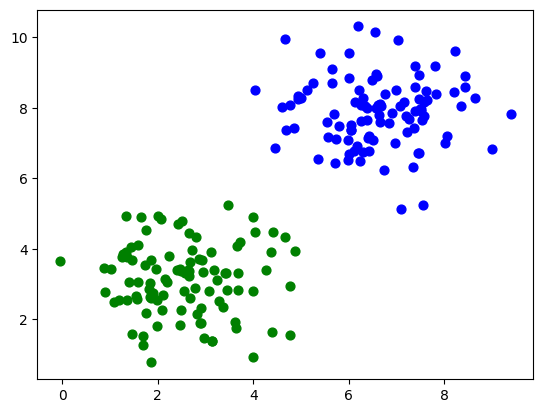

In [19]:
# Let us visualize the decision boundary:
fig, ax = plt.subplots()

# plotting learn data
colours = ('green', 'blue')

for n_class in range(2):
    ax.scatter(learn_data[learn_labels == n_class][:, 0],
               learn_data[learn_labels == n_class][:, 1],
               c=colours[n_class], s=40, label=str(n_class))

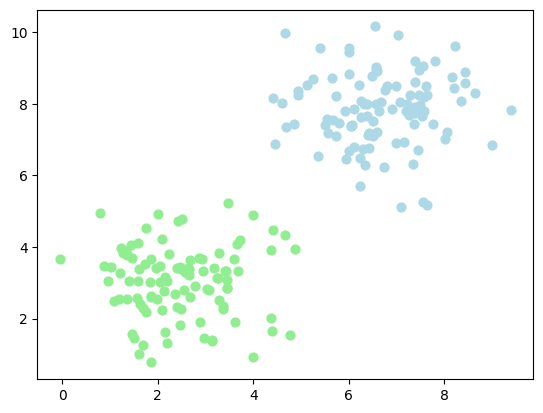

In [21]:
# plotting test data
colours = ('lightgreen', 'lightblue')

fig, ax = plt.subplots()

for n_class in range(2):
    ax.scatter(test_data[test_labels == n_class][:, 0],
               test_data[test_labels == n_class][:, 1],
               c=colours[n_class], s=40, label=str(n_class))

[0. 1. 2. 3. 4. 5. 6. 7. 8. 9.]
-1.5513529034664024 11.736643489707035


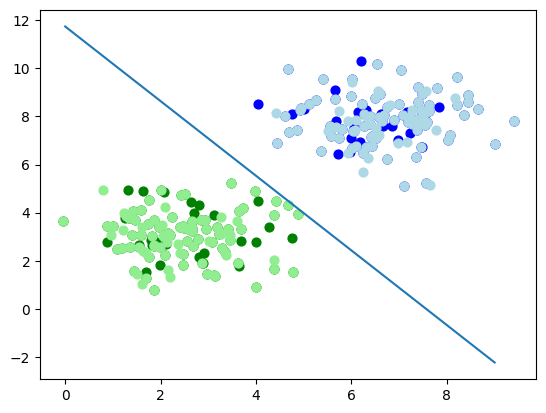

In [23]:
# Let us visualize the decision boundary:
fig, ax = plt.subplots()

# plotting learn data
colours = ('green', 'blue')

for n_class in range(2):
    ax.scatter(learn_data[learn_labels == n_class][:, 0],
               learn_data[learn_labels == n_class][:, 1],
               c=colours[n_class], s=40, label=str(n_class))

# plotting test data
colours = ('lightgreen', 'lightblue')
for n_class in range(2):
    ax.scatter(test_data[test_labels == n_class][:, 0],
               test_data[test_labels == n_class][:, 1],
               c=colours[n_class], s=40, label=str(n_class))

X = np.arange(np.max(samples[:, 0]))
print(X)

m = -p.weights[0] / p.weights[1]
c = -p.weights[2] / p.weights[1]
print(m, c)

ax.plot(X, m * X + c)
plt.plot()
plt.show()

In [ ]:
"""
In the following section, we will introduce the XOR problem for neural networks. It is the simplest example of
a non linearly separable neural network. It can be solved with an additional layer of neurons, which is called a
hidden layer.

"""